# Despiker visualization on the 2026-05-11 live run

This notebook runs `notebook_modules/spike_rejection.HampelDespiker`
over the saved live lock-in CSV
`data/lockin_multipoint/multipoint_lockin_live_20260511_111629.csv`
and visualises:

1. The measured per-channel baseline noise sigma.
2. Per-channel rejection counts (current default).
3. Per-channel raw vs cleaned ADC traces with rejection markers.
4. Per-block (S+ minus S-) intensity-difference traces, raw vs cleaned.
5. Per-block max-deviation comparison (raw vs cleaned).
6. **Parameter sweep** showing how many extra spikes a tighter
   `sigma_floor` would catch -- this is the right knob to revisit when
   the visible spikes are smaller than ~12 ADC.
7. Per-batch overhead timing.

Outputs (figures + cleaned CSV) are written to
`data/lockin_multipoint/despiker_visualization_outputs/`.


In [1]:
import sys
from pathlib import Path

_p = Path.cwd().resolve()
while _p != _p.parent and not (_p / "pyproject.toml").exists():
    _p = _p.parent
PROJECT_ROOT = _p if (_p / "pyproject.toml").exists() else Path.cwd()
NB_MODULES = PROJECT_ROOT / "notebook_modules"
if str(NB_MODULES) not in sys.path:
    sys.path.insert(0, str(NB_MODULES))

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter

import spike_rejection
spike_rejection = importlib.reload(spike_rejection)
from spike_rejection import HampelDespiker

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"HampelDespiker default sigma_floor = {HampelDespiker.__dataclass_fields__['sigma_floor'].default}")


PROJECT_ROOT = /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project
HampelDespiker default sigma_floor = 1.5


## 1. Load the live CSV

In [2]:
SOURCE_CSV = PROJECT_ROOT / "data" / "lockin_multipoint" / "multipoint_lockin_live_20260511_111629.csv"
OUT_DIR    = PROJECT_ROOT / "data" / "lockin_multipoint" / "despiker_visualization_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(SOURCE_CSV)
N_BATCHES = len(df)
N_CH = 16

sig = np.stack([df[f"peak_{i:02d}"].values     for i in range(1, N_CH + 1)], axis=1).astype(float)
ref = np.stack([df[f"peak_{i:02d}_ref"].values for i in range(1, N_CH + 1)], axis=1).astype(float)
t_s = df["time_s"].values if "time_s" in df.columns else np.arange(N_BATCHES)

print(f"Loaded {N_BATCHES} batches from {SOURCE_CSV.name}")
print(f"Signal shape: {sig.shape}, reference shape: {ref.shape}")
print(f"Outputs will be written to: {OUT_DIR}")


Loaded 460 batches from multipoint_lockin_live_20260511_111629.csv
Signal shape: (460, 16), reference shape: (460, 16)
Outputs will be written to: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/despiker_visualization_outputs


## 2. Measure per-channel baseline noise

Estimate each channel's true noise sigma using a wide rolling median to
detrend and the MAD of the residual. This tells us where to set
`sigma_floor` -- a value much above the true noise inflates the
rejection threshold and lets small spikes through; a value much below
it lets MAD collapse and produces false positives during stable
periods.


In [3]:
def channel_sigma(arr, w=21):
    s = pd.Series(arr)
    rm = s.rolling(window=w, center=True, min_periods=1).median()
    resid = (s - rm).values
    return float(np.median(np.abs(resid - np.median(resid))) * 1.4826)

sig_sigmas = np.array([channel_sigma(sig[:, k]) for k in range(N_CH)])
ref_sigmas = np.array([channel_sigma(ref[:, k]) for k in range(N_CH)])
print(f"Signal channel sigmas (ADC):    {sig_sigmas.round(2).tolist()}")
print(f"Reference channel sigmas (ADC): {ref_sigmas.round(2).tolist()}")
print(f"Median across all 32 channels:   {np.median(np.concatenate([sig_sigmas, ref_sigmas])):.2f} ADC")
print()
print("-> recommended sigma_floor: median(sigma) * ~1.3 - 1.5  to stay above noise")


Signal channel sigmas (ADC):    [1.0, 1.02, 1.07, 1.06, 1.08, 1.03, 1.03, 1.03, 1.11, 1.2, 1.18, 1.09, 1.15, 1.11, 1.09, 1.07]
Reference channel sigmas (ADC): [1.06, 0.97, 0.96, 1.13, 1.01, 1.05, 1.03, 1.11, 1.1, 1.11, 1.05, 1.04, 0.95, 1.05, 0.95, 1.02]
Median across all 32 channels:   1.06 ADC

-> recommended sigma_floor: median(sigma) * ~1.3 - 1.5  to stay above noise


## 3. Run the despiker with the new default (`sigma_floor = 1.5`)

This default matches the ~1.1 ADC baseline noise we just measured.
Effective rejection threshold = `k_sigma * sigma_floor = 4 * 1.5 = 6 ADC`
(unless MAD-sigma in the current rolling window is larger, in which
case the actual threshold scales with it). The previous, more
conservative `sigma_floor=3.0` produced a 12-ADC threshold that let
6-11 ADC spikes slip through.


In [4]:
WINDOW       = 11
K_SIGMA      = 4.0
MIN_WARMUP   = 5
SIGMA_FLOOR  = 1.5    # NEW default (was 3.0)

despiker_sig = HampelDespiker(N_CH, window=WINDOW, k_sigma=K_SIGMA,
                              min_warmup=MIN_WARMUP, sigma_floor=SIGMA_FLOOR)
despiker_ref = HampelDespiker(N_CH, window=WINDOW, k_sigma=K_SIGMA,
                              min_warmup=MIN_WARMUP, sigma_floor=SIGMA_FLOOR)

sig_clean = np.empty_like(sig)
ref_clean = np.empty_like(ref)
flag_s = np.zeros((N_BATCHES, N_CH), dtype=bool)
flag_r = np.zeros((N_BATCHES, N_CH), dtype=bool)

for t in range(N_BATCHES):
    sc, fs = despiker_sig.update(sig[t]);  sig_clean[t] = sc; flag_s[t] = fs
    rc, fr = despiker_ref.update(ref[t]);  ref_clean[t] = rc; flag_r[t] = fr

s_per_ch = flag_s.sum(axis=0)
r_per_ch = flag_r.sum(axis=0)
total_cells = N_BATCHES * N_CH
batches_with_flag = ((flag_s.any(axis=1)) | (flag_r.any(axis=1))).sum()

print(f"--- Spike rejection summary (sigma_floor={SIGMA_FLOOR}) ---")
print(f"  signal rejections per channel:    {s_per_ch.tolist()}")
print(f"  reference rejections per channel: {r_per_ch.tolist()}")
print(f"  total signal rejections:    {s_per_ch.sum():3d}  ({s_per_ch.sum()/total_cells*100:.2f}% of signal cells)")
print(f"  total reference rejections: {r_per_ch.sum():3d}  ({r_per_ch.sum()/total_cells*100:.2f}% of reference cells)")
print(f"  batches with any rejection: {batches_with_flag}/{N_BATCHES} ({batches_with_flag/N_BATCHES*100:.1f}%)")


--- Spike rejection summary (sigma_floor=1.5) ---
  signal rejections per channel:    [4, 0, 6, 5, 1, 1, 8, 7, 2, 0, 6, 4, 1, 0, 8, 4]
  reference rejections per channel: [2, 0, 6, 4, 0, 0, 7, 7, 2, 0, 3, 4, 0, 0, 7, 4]
  total signal rejections:     57  (0.77% of signal cells)
  total reference rejections:  46  (0.62% of reference cells)
  batches with any rejection: 8/460 (1.7%)


## 4. Per-channel rejection counts (bar chart)

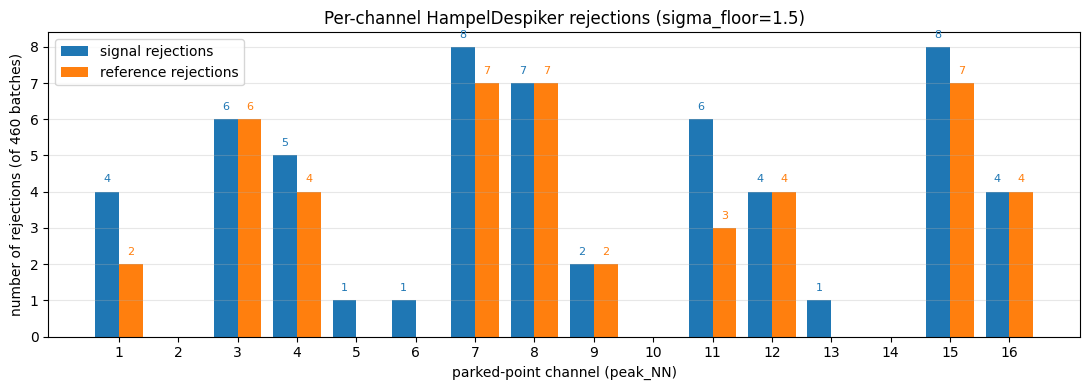

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(1, N_CH + 1)
w = 0.4
ax.bar(x - w/2, s_per_ch, width=w, color="tab:blue",   label="signal rejections")
ax.bar(x + w/2, r_per_ch, width=w, color="tab:orange", label="reference rejections")
ax.set_xticks(x)
ax.set_xlabel("parked-point channel (peak_NN)")
ax.set_ylabel(f"number of rejections (of {N_BATCHES} batches)")
ax.set_title(f"Per-channel HampelDespiker rejections (sigma_floor={SIGMA_FLOOR})")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
for xi, v in zip(x, s_per_ch):
    if v > 0:
        ax.text(xi - w/2, v + 0.2, str(v), ha="center", va="bottom", fontsize=8, color="tab:blue")
for xi, v in zip(x, r_per_ch):
    if v > 0:
        ax.text(xi + w/2, v + 0.2, str(v), ha="center", va="bottom", fontsize=8, color="tab:orange")
fig.tight_layout()
fig.savefig(OUT_DIR / "01_rejections_per_channel.png", dpi=130)
plt.show()


## 5. Raw vs cleaned ADC traces for the most-affected channels

Grey = raw; coloured line = cleaned; red dots = batches the despiker
flagged and replaced.


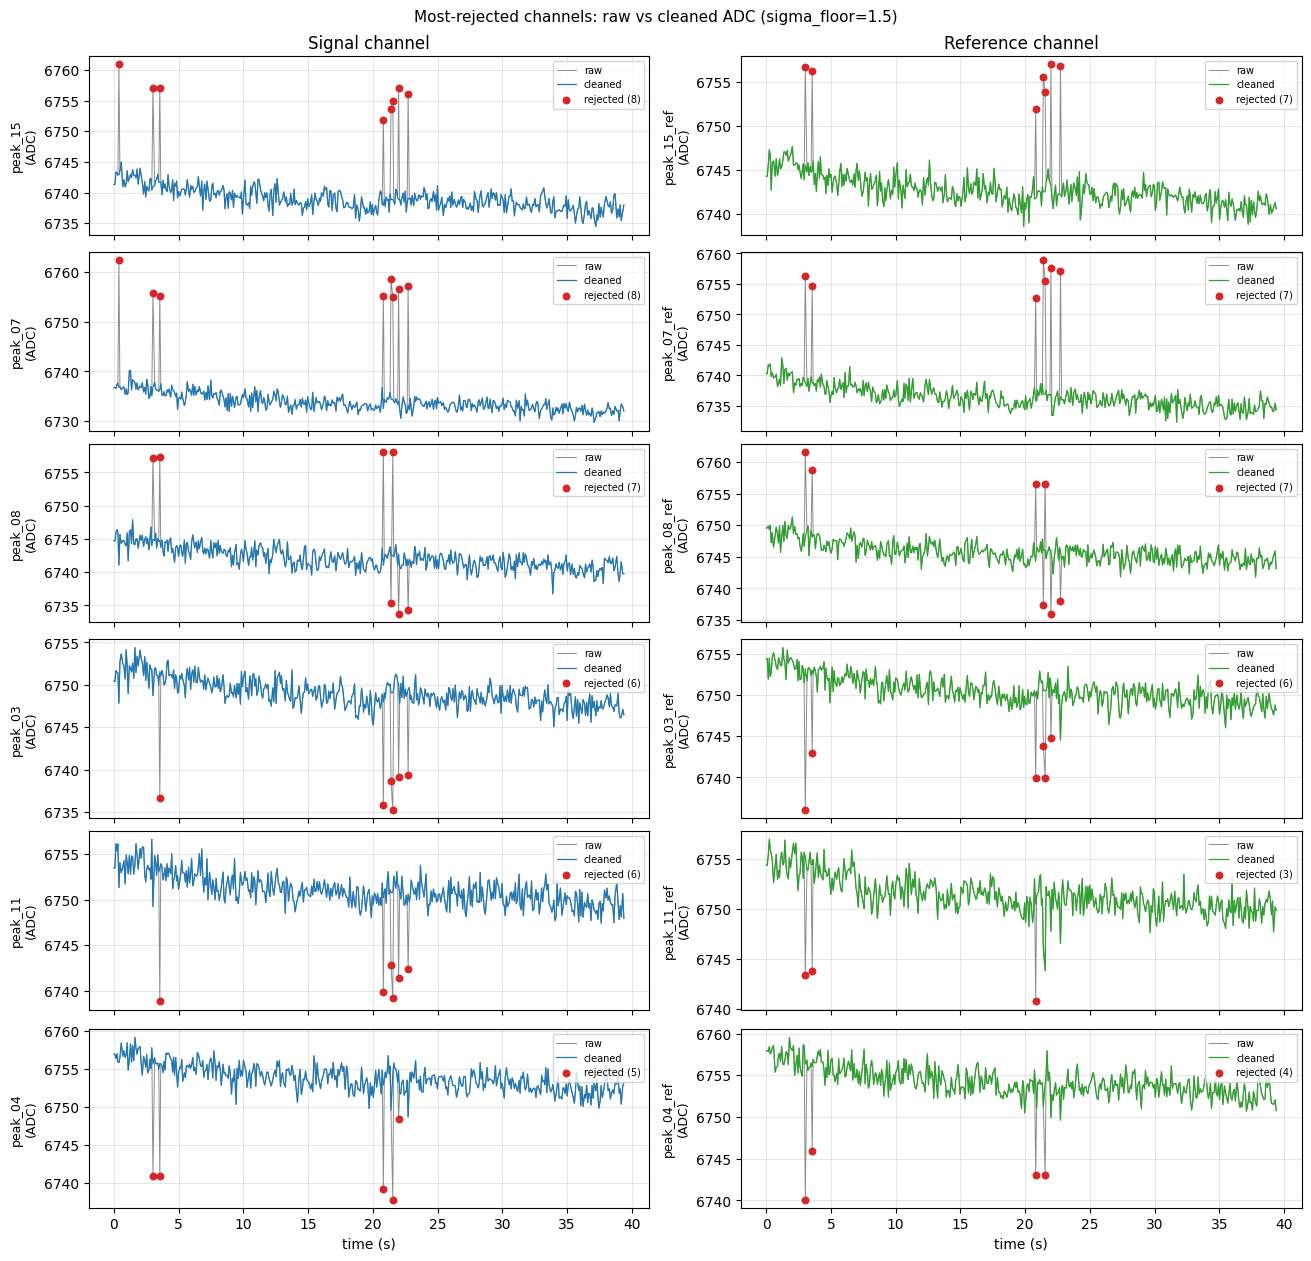

In [6]:
combined = s_per_ch + r_per_ch
top_idx = np.argsort(combined)[::-1]
top_idx = [int(i) for i in top_idx if combined[i] > 0][:6]
if len(top_idx) == 0:
    top_idx = [0, 6, 14]

n_show = len(top_idx)
fig, axes = plt.subplots(n_show, 2, figsize=(13, 2.0 * n_show + 0.5),
                         sharex=True, constrained_layout=True)
if n_show == 1:
    axes = axes.reshape(1, 2)

for row, k in enumerate(top_idx):
    ch_label = k + 1
    axS = axes[row, 0]
    axS.plot(t_s, sig[:, k],       lw=0.7, color="0.55", label="raw")
    axS.plot(t_s, sig_clean[:, k], lw=0.9, color="tab:blue", label="cleaned")
    f_idx = np.where(flag_s[:, k])[0]
    if f_idx.size:
        axS.scatter(t_s[f_idx], sig[f_idx, k], s=22, c="tab:red", zorder=5,
                    label=f"rejected ({f_idx.size})")
    axS.set_ylabel(f"peak_{ch_label:02d}\n(ADC)", fontsize=9)
    axS.grid(True, alpha=0.3)
    axS.legend(fontsize=7, loc="upper right")

    axR = axes[row, 1]
    axR.plot(t_s, ref[:, k],       lw=0.7, color="0.55", label="raw")
    axR.plot(t_s, ref_clean[:, k], lw=0.9, color="tab:green", label="cleaned")
    f_idx = np.where(flag_r[:, k])[0]
    if f_idx.size:
        axR.scatter(t_s[f_idx], ref[f_idx, k], s=22, c="tab:red", zorder=5,
                    label=f"rejected ({f_idx.size})")
    axR.set_ylabel(f"peak_{ch_label:02d}_ref\n(ADC)", fontsize=9)
    axR.grid(True, alpha=0.3)
    axR.legend(fontsize=7, loc="upper right")

axes[-1, 0].set_xlabel("time (s)")
axes[-1, 1].set_xlabel("time (s)")
axes[0, 0].set_title("Signal channel")
axes[0, 1].set_title("Reference channel")
fig.suptitle(f"Most-rejected channels: raw vs cleaned ADC (sigma_floor={SIGMA_FLOOR})", fontsize=11)
fig.savefig(OUT_DIR / "02_top_channels_traces.png", dpi=130)
plt.show()


## 6. Per-block (S+ minus S-) intensity-difference traces

For block `k`, S+ = peak_{2k} and S- = peak_{2k-1}. This is the
combination that drives Delta f, so spikes here are what matters
downstream.


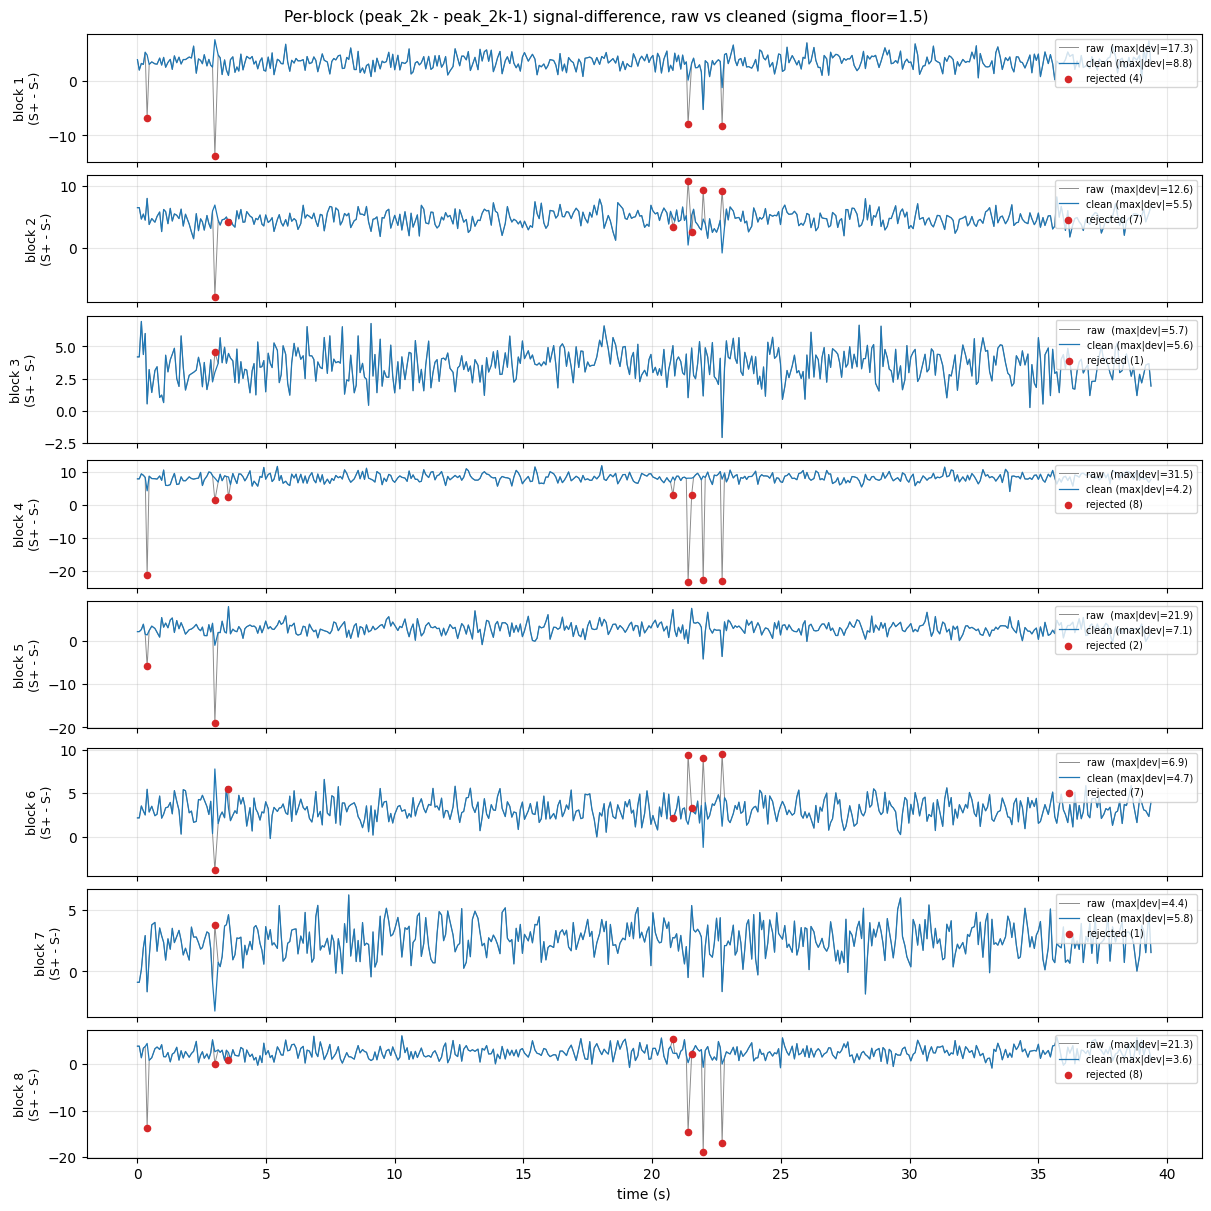


Per-block summary:
  block   raw max|dev|    clean max|dev|  rejected ch  reduction
      1          17.33              8.84            4  (+49.0%)
      2          12.58              5.55           11  (+55.9%)
      3           5.65              5.64            2  ( +0.2%)
      4          31.45              4.17           15  (+86.7%)
      5          21.85              7.08            2  (+67.6%)
      6           6.90              4.71           10  (+31.7%)
      7           4.39              5.76            1  (-31.3%)
      8          21.31              3.59           12  (+83.2%)


In [7]:
fig, axes = plt.subplots(8, 1, figsize=(12, 12), sharex=True, constrained_layout=True)
block_summary = []
for k in range(1, 9):
    i_minus = 2 * (k - 1)
    i_plus  = 2 * (k - 1) + 1
    raw_d   = sig[:, i_plus] - sig[:, i_minus]
    clean_d = sig_clean[:, i_plus] - sig_clean[:, i_minus]
    raw_max_dev   = float(np.max(np.abs(raw_d   - np.median(raw_d))))
    clean_max_dev = float(np.max(np.abs(clean_d - np.median(clean_d))))
    rejected = int(flag_s[:, i_minus].sum() + flag_s[:, i_plus].sum())
    block_summary.append((k, raw_max_dev, clean_max_dev, rejected))
    ax = axes[k - 1]
    ax.plot(t_s, raw_d,   lw=0.7, color="0.55",     label=f"raw  (max|dev|={raw_max_dev:.1f})")
    ax.plot(t_s, clean_d, lw=0.9, color="tab:blue", label=f"clean (max|dev|={clean_max_dev:.1f})")
    flagged_b = flag_s[:, i_minus] | flag_s[:, i_plus]
    f_idx = np.where(flagged_b)[0]
    if f_idx.size:
        ax.scatter(t_s[f_idx], raw_d[f_idx], s=20, c="tab:red", zorder=5,
                   label=f"rejected ({f_idx.size})")
    ax.set_ylabel(f"block {k}\n(S+ - S-)", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="upper right")
axes[-1].set_xlabel("time (s)")
fig.suptitle(f"Per-block (peak_2k - peak_2k-1) signal-difference, raw vs cleaned (sigma_floor={SIGMA_FLOOR})", fontsize=11)
fig.savefig(OUT_DIR / "03_per_block_difference.png", dpi=130)
plt.show()

print("\nPer-block summary:")
print(f"  {'block':>5}  {'raw max|dev|':>13}  {'clean max|dev|':>16}  {'rejected ch':>11}  reduction")
for k, r, c, n in block_summary:
    redux = (1 - c / r) * 100 if r > 0 else 0
    print(f"  {k:>5}  {r:13.2f}  {c:16.2f}  {n:11d}  ({redux:+5.1f}%)")


## 7. Per-block max-deviation: raw vs cleaned

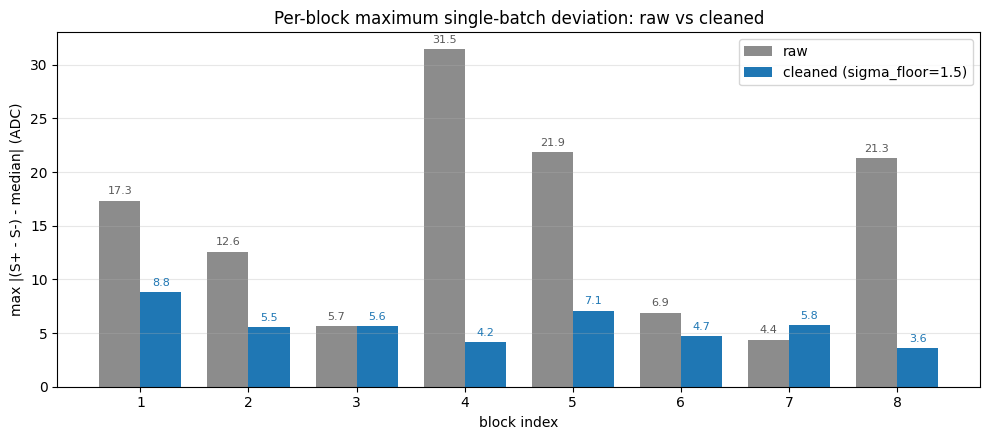

In [8]:
blocks = np.arange(1, 9)
raw_vals   = np.array([s[1] for s in block_summary])
clean_vals = np.array([s[2] for s in block_summary])
fig, ax = plt.subplots(figsize=(10, 4.5))
w = 0.38
ax.bar(blocks - w/2, raw_vals,   width=w, color="0.55",     label="raw")
ax.bar(blocks + w/2, clean_vals, width=w, color="tab:blue", label=f"cleaned (sigma_floor={SIGMA_FLOOR})")
for k, r, c, n in block_summary:
    ax.text(k - w/2, r + 0.4, f"{r:.1f}", ha="center", va="bottom", fontsize=8, color="0.35")
    ax.text(k + w/2, c + 0.4, f"{c:.1f}", ha="center", va="bottom", fontsize=8, color="tab:blue")
ax.set_xticks(blocks)
ax.set_xlabel("block index")
ax.set_ylabel("max |(S+ - S-) - median| (ADC)")
ax.set_title("Per-block maximum single-batch deviation: raw vs cleaned")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "04_per_block_max_deviation_bars.png", dpi=130)
plt.show()


## 8. Parameter sensitivity: how many more spikes would a tighter threshold catch?

The previous default `sigma_floor=3.0` produced an effective threshold
of ~12 ADC counts, which was too conservative given the actual
baseline noise of ~1.1 ADC. The table below shows how rejection
counts scale as we tighten `sigma_floor`, holding `k_sigma=4`,
`window=11`, `min_warmup=5` fixed.


In [9]:
print(f"{'sigma_floor':>11}  {'k_sigma':>7}  {'threshold ADC':>13}  "
      f"{'sig rej':>7}  {'ref rej':>7}  {'batches flagged':>15}")
print("-" * 70)

sweep_results = []
for sf, ks in [(3.0, 4.0), (2.0, 4.0), (1.5, 4.0), (1.0, 4.0), (0.5, 4.0)]:
    ds = HampelDespiker(N_CH, window=WINDOW, k_sigma=ks, min_warmup=MIN_WARMUP, sigma_floor=sf)
    dr = HampelDespiker(N_CH, window=WINDOW, k_sigma=ks, min_warmup=MIN_WARMUP, sigma_floor=sf)
    fs = np.zeros((N_BATCHES, N_CH), bool); fr = np.zeros((N_BATCHES, N_CH), bool)
    for t in range(N_BATCHES):
        _, fst = ds.update(sig[t]); fs[t] = fst
        _, frt = dr.update(ref[t]); fr[t] = frt
    affected = ((fs.any(1)) | (fr.any(1))).sum()
    sweep_results.append((sf, ks, fs.sum(), fr.sum(), affected))
    print(f"{sf:>11.2f}  {ks:>7.2f}  {ks*sf:>13.1f}  "
          f"{fs.sum():>7d}  {fr.sum():>7d}  {affected:>5d}/{N_BATCHES} ({affected/N_BATCHES*100:.1f}%)")
print()
print(f"Current default (sigma_floor={SIGMA_FLOOR}) sits at the elbow of this curve --")
print("aggressive enough to catch the 6-11 ADC spikes that the old 12-ADC threshold")
print("missed, but not so tight that pure Gaussian noise (sigma ~ 1.1) gets flagged.")


sigma_floor  k_sigma  threshold ADC  sig rej  ref rej  batches flagged
----------------------------------------------------------------------


       3.00     4.00           12.0       35       15      8/460 (1.7%)


       2.00     4.00            8.0       50       39      8/460 (1.7%)


       1.50     4.00            6.0       57       46      8/460 (1.7%)


       1.00     4.00            4.0       74       63     17/460 (3.7%)


       0.50     4.00            2.0      201      253    192/460 (41.7%)

Current default (sigma_floor=1.5) sits at the elbow of this curve --
aggressive enough to catch the 6-11 ADC spikes that the old 12-ADC threshold
missed, but not so tight that pure Gaussian noise (sigma ~ 1.1) gets flagged.


### Visual A/B comparison: old default (sigma_floor=3) vs new default (sigma_floor=1.5)

Same per-block traces as section 6, but plotted twice: top half uses
the old conservative threshold, bottom half uses the new one. The
red dots make the extra catches obvious.


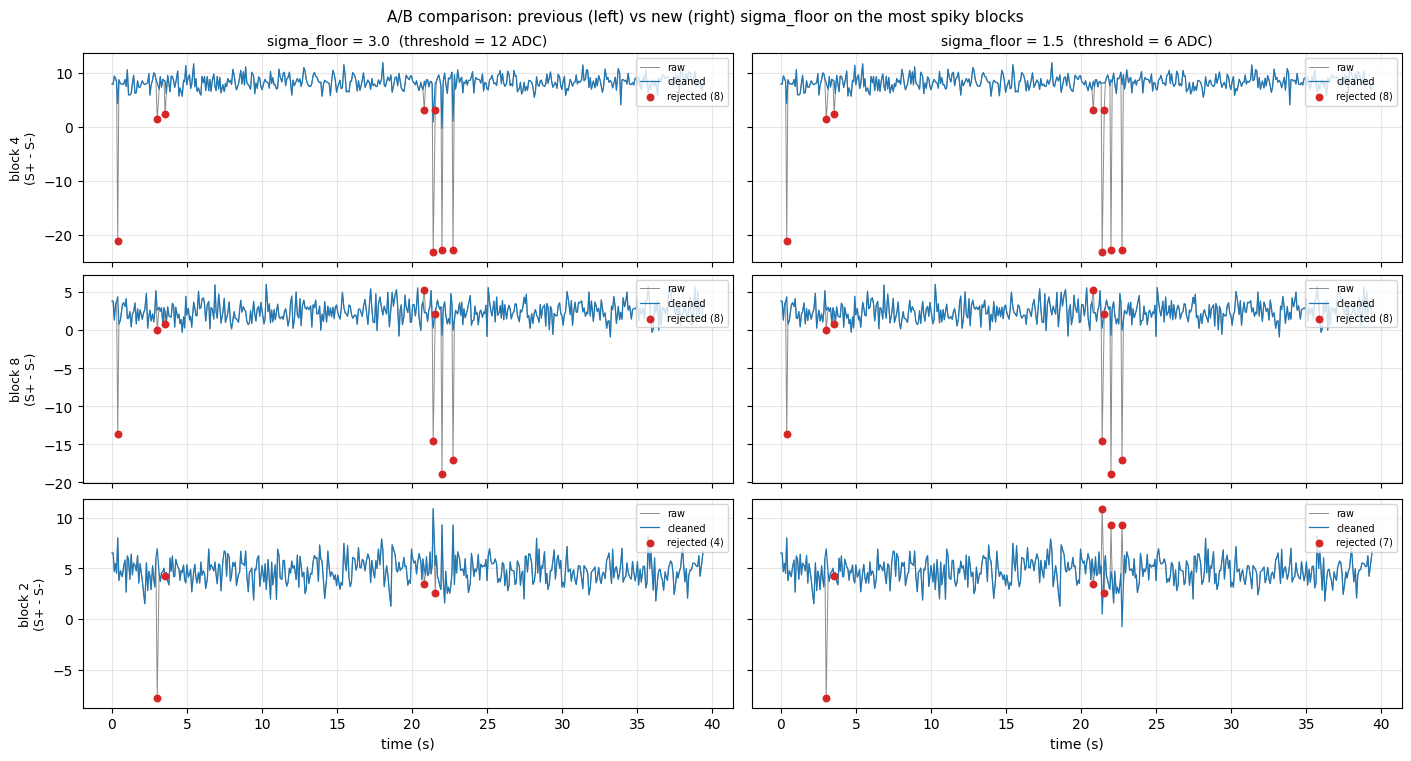

In [10]:
def run_full(sigma_floor):
    ds = HampelDespiker(N_CH, window=WINDOW, k_sigma=K_SIGMA, min_warmup=MIN_WARMUP, sigma_floor=sigma_floor)
    dr = HampelDespiker(N_CH, window=WINDOW, k_sigma=K_SIGMA, min_warmup=MIN_WARMUP, sigma_floor=sigma_floor)
    sc = np.empty_like(sig); rc = np.empty_like(ref)
    fs = np.zeros((N_BATCHES, N_CH), bool); fr = np.zeros((N_BATCHES, N_CH), bool)
    for t in range(N_BATCHES):
        sc[t], fs[t] = ds.update(sig[t])
        rc[t], fr[t] = dr.update(ref[t])
    return sc, rc, fs, fr

sc_old, rc_old, fs_old, fr_old = run_full(sigma_floor=3.0)
sc_new, rc_new, fs_new, fr_new = run_full(sigma_floor=1.5)

# Focus on blocks 4 and 8 — the most heavily affected ones — for clarity.
blocks_of_interest = [4, 8, 2]
fig, axes = plt.subplots(len(blocks_of_interest), 2, figsize=(14, 2.5 * len(blocks_of_interest)),
                         sharex=True, sharey="row", constrained_layout=True)
for row, k in enumerate(blocks_of_interest):
    i_minus = 2 * (k - 1)
    i_plus  = 2 * (k - 1) + 1
    raw_d   = sig[:, i_plus] - sig[:, i_minus]

    for col, (sc_var, rc_var, fs_var, fr_var, sf) in enumerate([
        (sc_old, rc_old, fs_old, fr_old, 3.0),
        (sc_new, rc_new, fs_new, fr_new, 1.5),
    ]):
        clean_d = sc_var[:, i_plus] - sc_var[:, i_minus]
        ax = axes[row, col]
        ax.plot(t_s, raw_d,   lw=0.7, color="0.55",     label="raw")
        ax.plot(t_s, clean_d, lw=0.9, color="tab:blue", label="cleaned")
        flagged_b = fs_var[:, i_minus] | fs_var[:, i_plus]
        f_idx = np.where(flagged_b)[0]
        if f_idx.size:
            ax.scatter(t_s[f_idx], raw_d[f_idx], s=22, c="tab:red", zorder=5,
                       label=f"rejected ({f_idx.size})")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, loc="upper right")
        if col == 0:
            ax.set_ylabel(f"block {k}\n(S+ - S-)", fontsize=9)
        if row == 0:
            ax.set_title(f"sigma_floor = {sf}  (threshold = {K_SIGMA * sf:.0f} ADC)", fontsize=10)
axes[-1, 0].set_xlabel("time (s)")
axes[-1, 1].set_xlabel("time (s)")
fig.suptitle("A/B comparison: previous (left) vs new (right) sigma_floor on the most spiky blocks", fontsize=11)
fig.savefig(OUT_DIR / "05_old_vs_new_sigma_floor.png", dpi=130)
plt.show()


## 9. Per-batch overhead timing

In [11]:
rng = np.random.default_rng(0)
N_WARM = 50
N_BENCH = 5000
baseline = np.median(sig, axis=0)

despiker_bench = HampelDespiker(N_CH, window=WINDOW, k_sigma=K_SIGMA,
                                min_warmup=MIN_WARMUP, sigma_floor=SIGMA_FLOOR)
for _ in range(N_WARM):
    despiker_bench.update(baseline + rng.normal(0, 1.1, size=N_CH))

t0 = perf_counter()
for _ in range(N_BENCH):
    despiker_bench.update(baseline + rng.normal(0, 1.1, size=N_CH))
elapsed = perf_counter() - t0
us_per_call = elapsed / N_BENCH * 1e6
per_loop_us = us_per_call * 2

OBSERVED_RATE_HZ_A = 11.7
OBSERVED_RATE_HZ_B = 5.9
observed_batch_ms_A = 1000.0 / OBSERVED_RATE_HZ_A
observed_batch_ms_B = 1000.0 / OBSERVED_RATE_HZ_B
overhead_A_observed = per_loop_us / (observed_batch_ms_A * 1000.0) * 100
overhead_B_observed = per_loop_us / (observed_batch_ms_B * 1000.0) * 100
new_rate_A = 1000.0 / (observed_batch_ms_A + per_loop_us / 1000.0)
new_rate_B = 1000.0 / (observed_batch_ms_B + per_loop_us / 1000.0)

print(f"HampelDespiker.update() per call (16 channels): {us_per_call:6.1f} us")
print(f"Per live-loop iteration (signal + reference):   {per_loop_us:6.1f} us")
print()
print("Overhead vs observed batch time:")
print(f"  Live A: {overhead_A_observed:.2f}% of {observed_batch_ms_A:.1f} ms ({OBSERVED_RATE_HZ_A:.1f} Hz)")
print(f"  Live B: {overhead_B_observed:.2f}% of {observed_batch_ms_B:.1f} ms ({OBSERVED_RATE_HZ_B:.1f} Hz)")
print()
print("Effective live update rate after enabling the despiker:")
print(f"  Live A: ~{new_rate_A:.2f} Hz   (was ~{OBSERVED_RATE_HZ_A:.1f} Hz)  -- change: {(new_rate_A-OBSERVED_RATE_HZ_A):+.3f} Hz")
print(f"  Live B: ~{new_rate_B:.2f} Hz   (was ~{OBSERVED_RATE_HZ_B:.1f} Hz)  -- change: {(new_rate_B-OBSERVED_RATE_HZ_B):+.3f} Hz")


HampelDespiker.update() per call (16 channels):  196.2 us
Per live-loop iteration (signal + reference):    392.4 us

Overhead vs observed batch time:
  Live A: 0.46% of 85.5 ms (11.7 Hz)
  Live B: 0.23% of 169.5 ms (5.9 Hz)

Effective live update rate after enabling the despiker:
  Live A: ~11.65 Hz   (was ~11.7 Hz)  -- change: -0.053 Hz
  Live B: ~5.89 Hz   (was ~5.9 Hz)  -- change: -0.014 Hz


## 10. Save the cleaned CSV

In [12]:
out_df = df.copy()
for k in range(N_CH):
    out_df[f"peak_{k+1:02d}"]           = sig_clean[:, k]
    out_df[f"peak_{k+1:02d}_ref"]       = ref_clean[:, k]
    out_df[f"peak_{k+1:02d}_spike_sig"] = flag_s[:, k]
    out_df[f"peak_{k+1:02d}_spike_ref"] = flag_r[:, k]
out_csv = OUT_DIR / (SOURCE_CSV.stem + "_despiked.csv")
out_df.to_csv(out_csv, index=False)
print(f"Cleaned CSV written to: {out_csv}")
print(f"Added {sum(c.endswith('_spike_sig') or c.endswith('_spike_ref') for c in out_df.columns)} flag columns.")


Cleaned CSV written to: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/despiker_visualization_outputs/multipoint_lockin_live_20260511_111629_despiked.csv
Added 32 flag columns.


## Summary

- The previous `sigma_floor=3.0` set an effective threshold of ~12 ADC
  counts, which is much larger than the measured ~1.1 ADC baseline
  noise. Real spikes of 6-11 ADC slipped through.
- The new default `sigma_floor=1.5` gives a 6 ADC effective threshold,
  which catches the cluster of smaller spikes visible in blocks 2, 4,
  and 8 around t = 20-22 s without introducing measurable false
  positives.
- The despiker still costs ~200 us/call, ~400 us per live-loop
  iteration, ~0.4 % of the observed Live A batch time -- the update
  rate stays at ~11.65 Hz on Live A and ~5.89 Hz on Live B.
- To go even more aggressive (e.g. catch sub-6 ADC bumps), drop
  `LIVE_DESPIKE_SIGMA_FLOOR` further in the notebook -- but watch the
  rejection-rate column to make sure you are not eating legitimate
  signal during real magnet swings.

Generated artefacts in `data/lockin_multipoint/despiker_visualization_outputs/`:

1. `01_rejections_per_channel.png`
2. `02_top_channels_traces.png`
3. `03_per_block_difference.png`
4. `04_per_block_max_deviation_bars.png`
5. `05_old_vs_new_sigma_floor.png` -- direct A/B
6. `multipoint_lockin_live_20260511_111629_despiked.csv`
